# Homework 02: Multi-Class Classification with Neural Networks

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

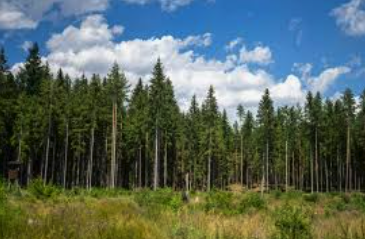

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [4]:
 # Perform train-test split, keeping both stratified, then standardize

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=random_seed
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.3525 - loss: 1.7448
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5404 - loss: 1.3065
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5912 - loss: 1.0673
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6240 - loss: 0.9500
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6432 - loss: 0.8844
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6583 - loss: 0.8431
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6698 - loss: 0.8142
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6786 - loss: 0.7921
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6841 - loss: 0.7736
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6895 - loss: 0.7575
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6960 - loss: 0.7430
Epoch 12/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

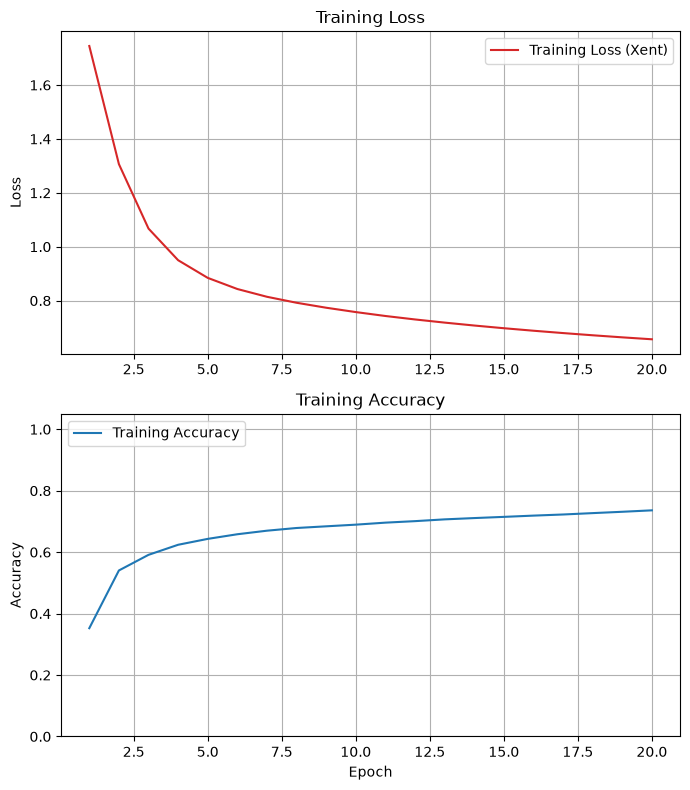

Final Training Loss:     0.6566
Final Training Accuracy: 0.7361


In [5]:
# Your code here

def build_model(learning_rate=0.0001, lr_schedule=None):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])
    lr = lr_schedule if lr_schedule is not None else learning_rate
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)
plot_history(history)


In [6]:
# Set a1a to the final training accuracy at epoch 20

a1a =  history.history['accuracy'][-1]             # Replace 0.0 with your answer

In [7]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7361


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!

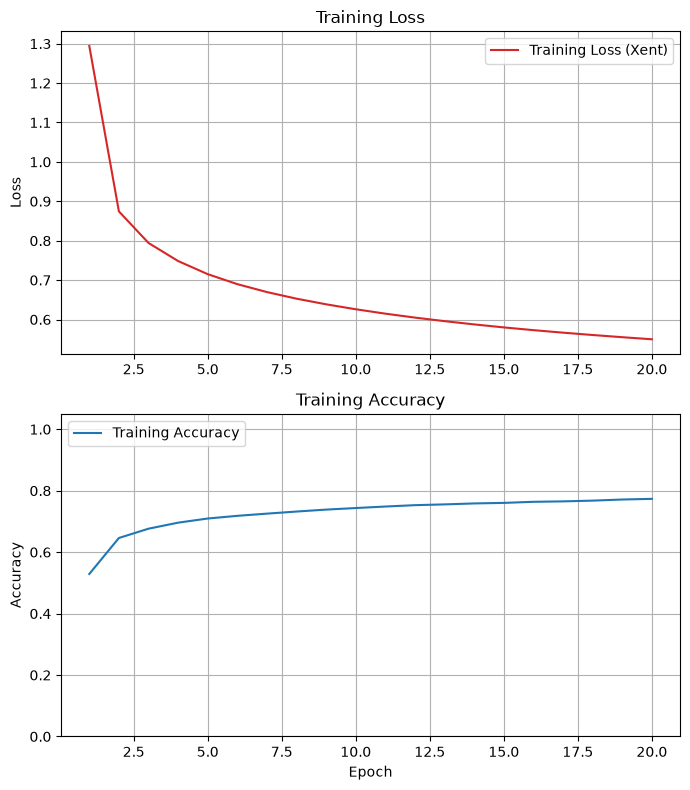

Final Training Loss:     0.5498
Final Training Accuracy: 0.7735


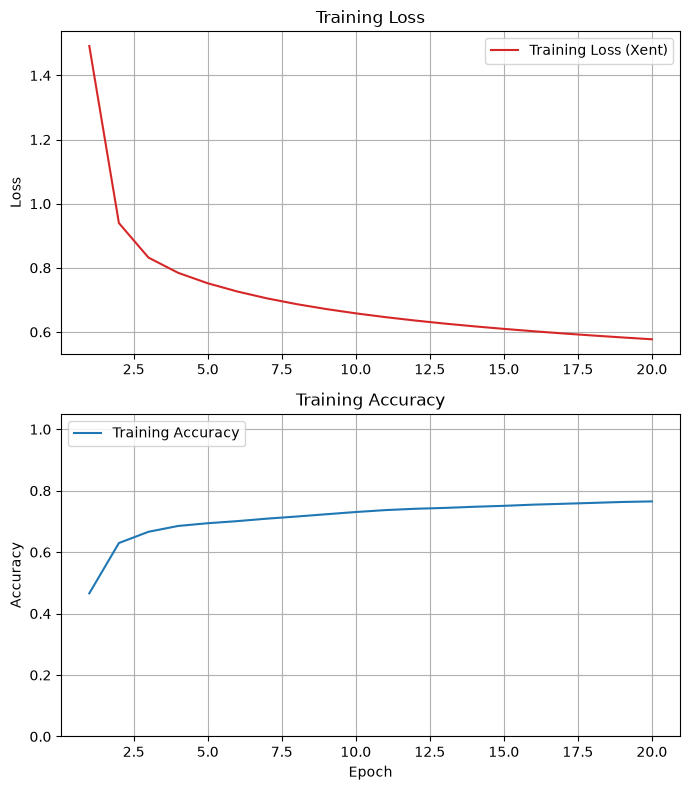

Final Training Loss:     0.5772
Final Training Accuracy: 0.7651


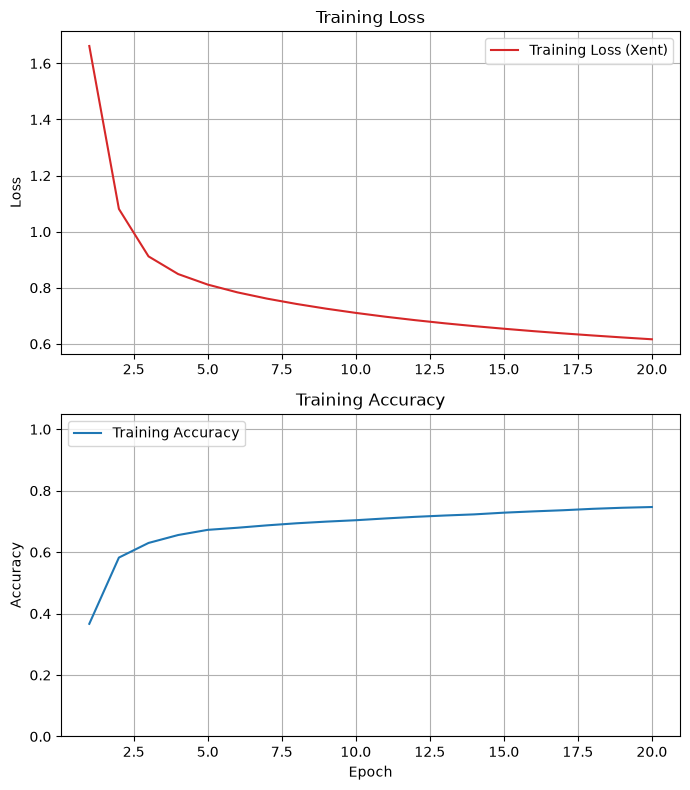

Final Training Loss:     0.6164
Final Training Accuracy: 0.7469


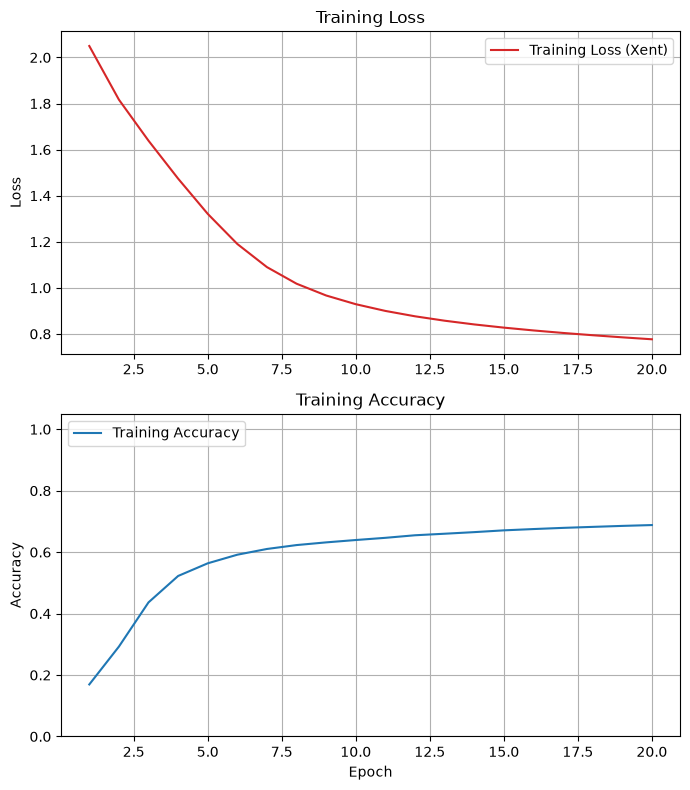

Final Training Loss:     0.7767
Final Training Accuracy: 0.6882


In [8]:
results = {}
for bs in [4, 8, 16, 128]:
    model = build_model()
    history = model.fit(X_train, y_train, epochs=20, batch_size=bs, verbose=0)
    plot_history(history)
    results[bs] = history.history['accuracy'][-1]


In [9]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = max(results, key=results.get)             # Replace 0 with your answer

In [10]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [11]:
# Set a2b to the best accuracy score found

a2b = results[a2a]             # Replace 0.0 with your answer

In [12]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7735


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.


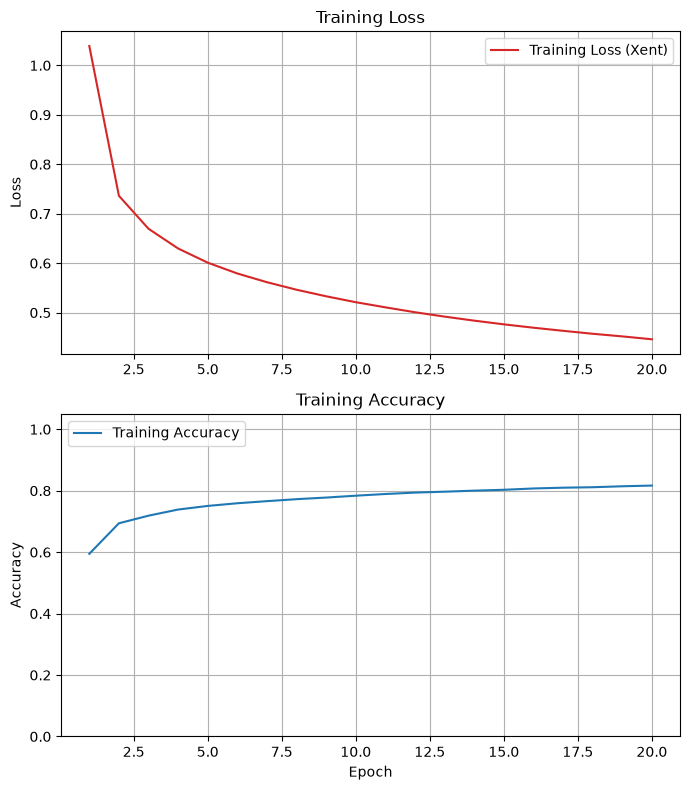

Final Training Loss:     0.4461
Final Training Accuracy: 0.8167


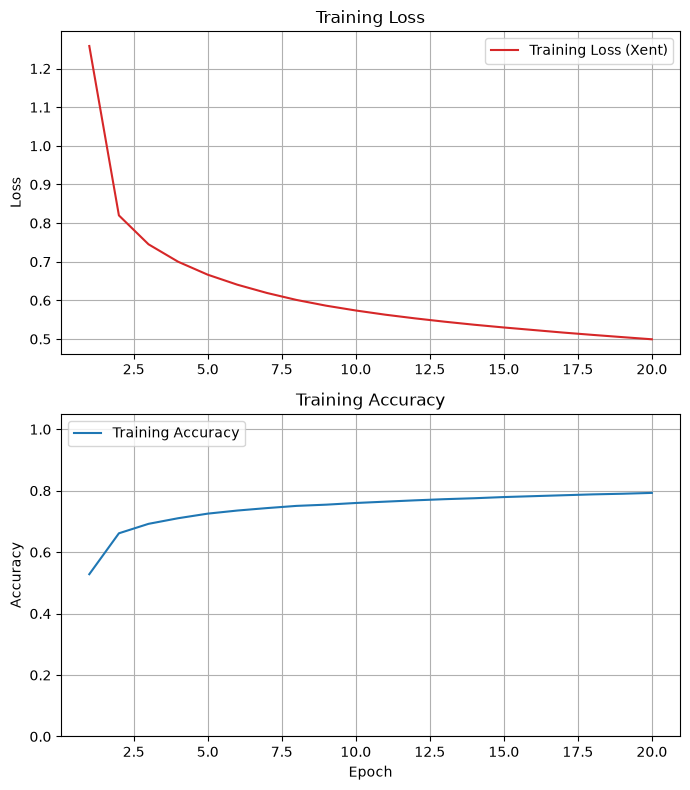

Final Training Loss:     0.4993
Final Training Accuracy: 0.7928


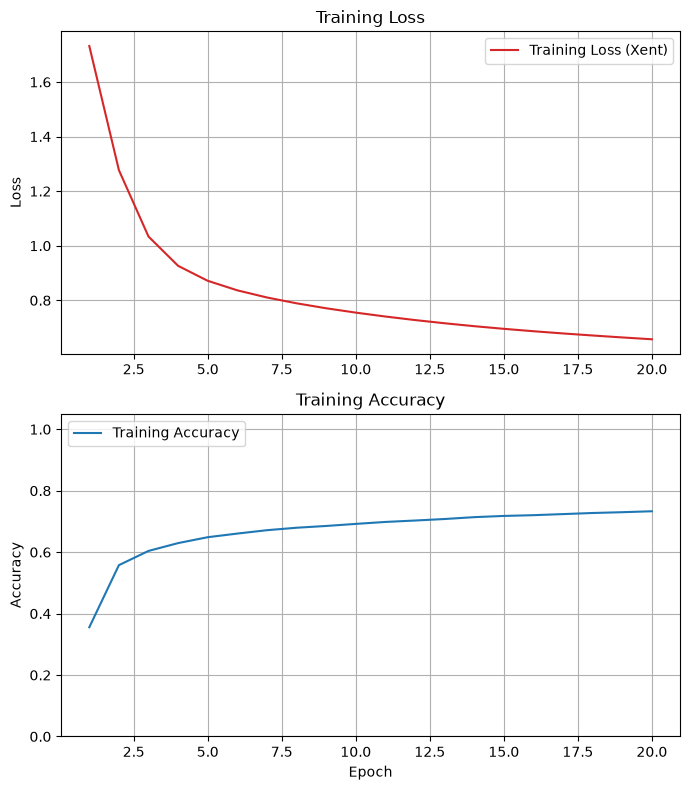

Final Training Loss:     0.6574
Final Training Accuracy: 0.7331


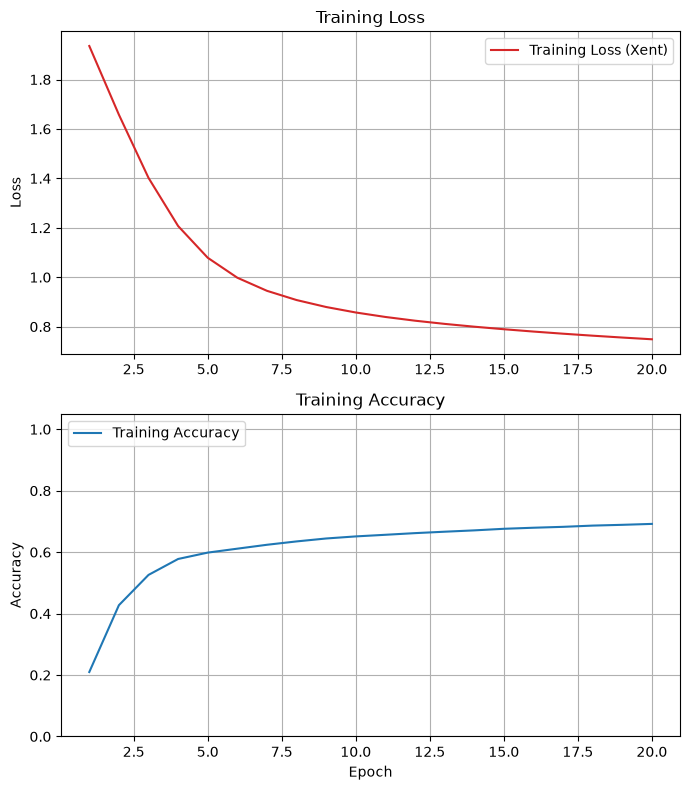

Final Training Loss:     0.7489
Final Training Accuracy: 0.6919


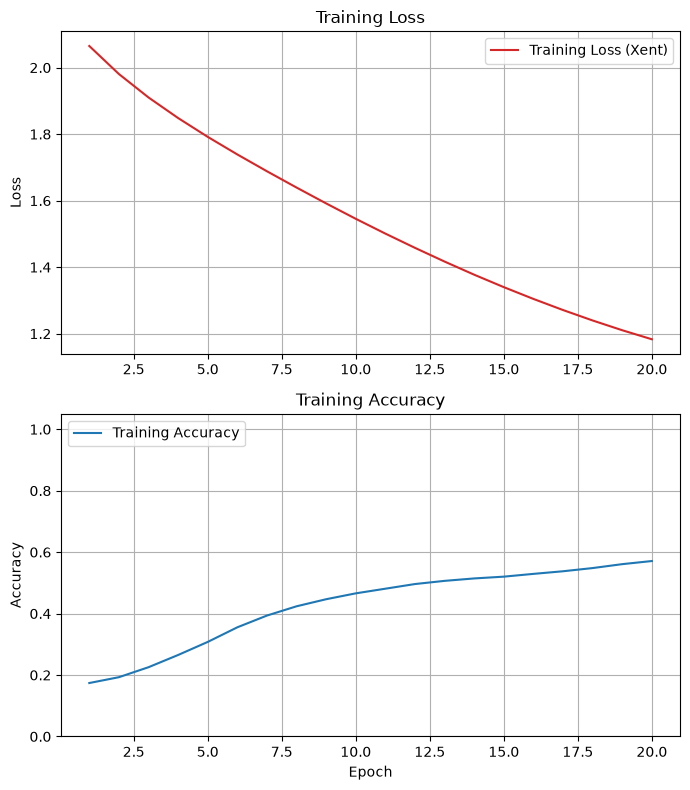

Final Training Loss:     1.1831
Final Training Accuracy: 0.5711


In [13]:
results_lr = {}
for lr in [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]:
    model = build_model(learning_rate=lr)
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    plot_history(history)
    results_lr[lr] = history.history['accuracy'][-1]


In [14]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = max(results_lr, key=results_lr.get)             # Replace 0.0 with your answer

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [16]:
# Set a3b to the accuracy found by the best learning rate

a3b = results_lr[a3a]             # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8167


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

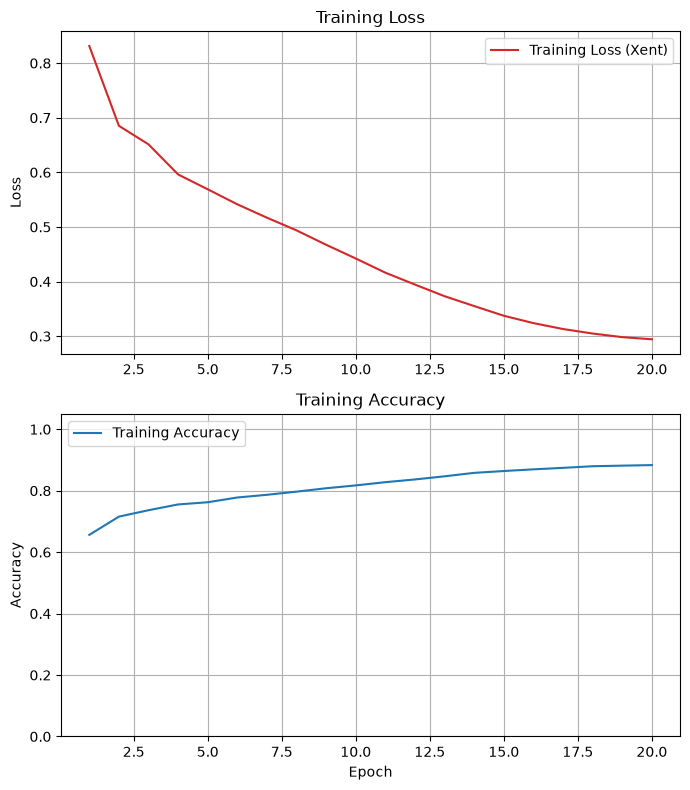

Final Training Loss:     0.2943
Final Training Accuracy: 0.8833


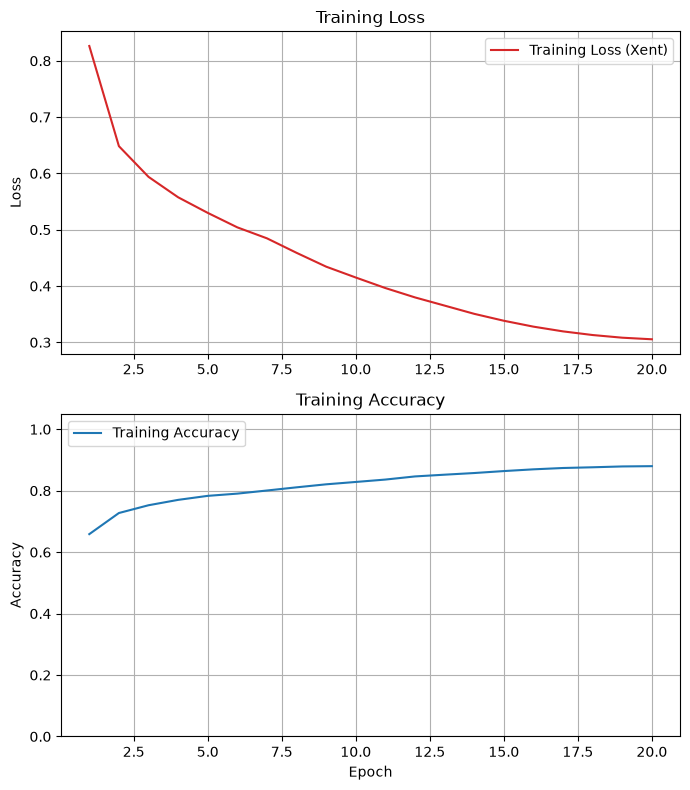

Final Training Loss:     0.3054
Final Training Accuracy: 0.8799


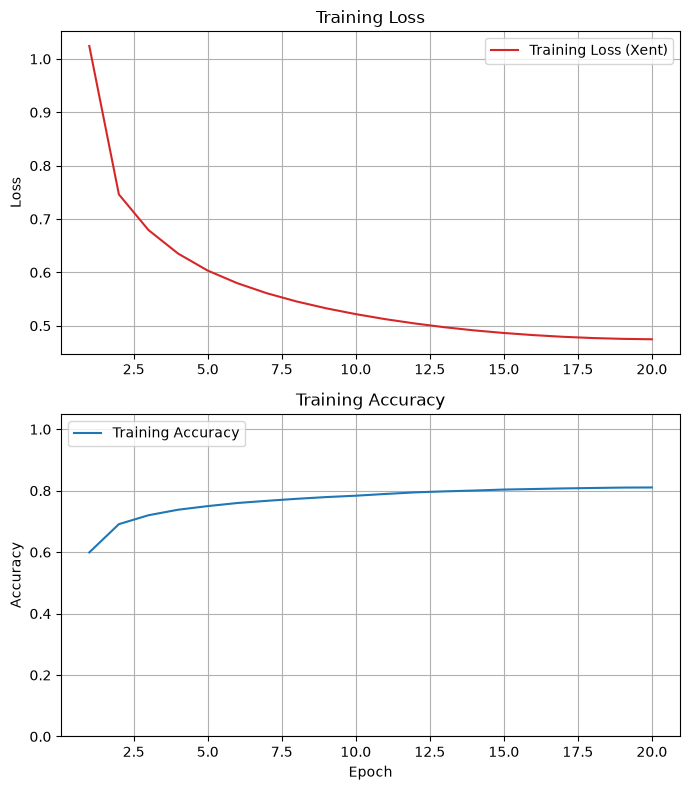

Final Training Loss:     0.4747
Final Training Accuracy: 0.8105


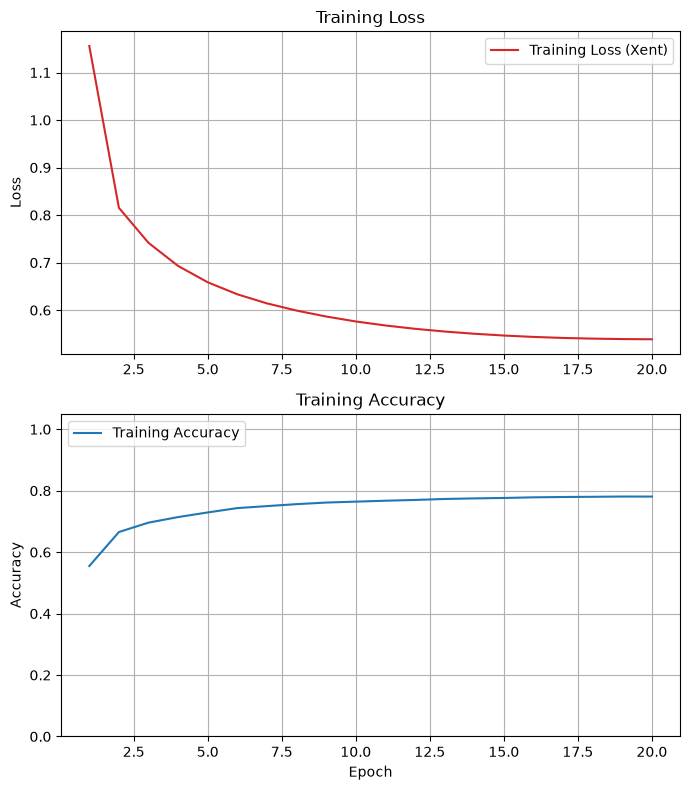

Final Training Loss:     0.5388
Final Training Accuracy: 0.7809


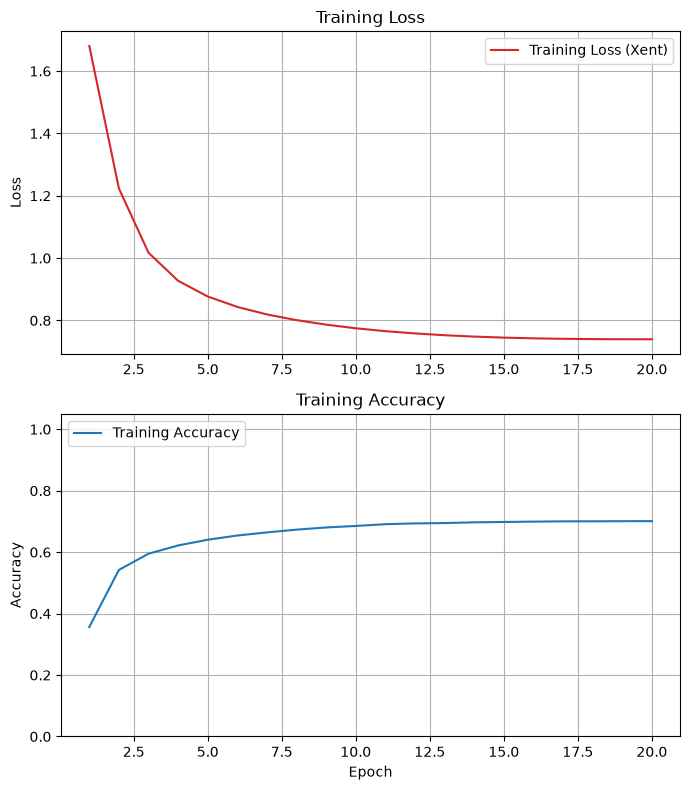

Final Training Loss:     0.7396
Final Training Accuracy: 0.7009


In [18]:
results_cd = {}
steps_per_epoch = len(X_train) // 32
for init_lr in [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]:
    schedule = CosineDecay(initial_learning_rate=init_lr, decay_steps=20 * steps_per_epoch)
    model = build_model(lr_schedule=schedule)
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    plot_history(history)
    results_cd[init_lr] = history.history['accuracy'][-1]



In [19]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = max(results_cd, key=results_cd.get)             # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [21]:
# Set a4b to the best accuracy found

a4b = results_cd[a4a]             # Replace 0.0 with your answer

In [22]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8833


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6519 - loss: 0.8261
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7141 - loss: 0.6772
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7342 - loss: 0.6270
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7515 - loss: 0.5995
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7684 - loss: 0.5631
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7811 - loss: 0.5352
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7900 - loss: 0.5074
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8035 - loss: 0.4818
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8163 - loss: 0.4570
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8244 - loss: 0.4327
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8342 - loss: 0.4086
Epoch 12/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

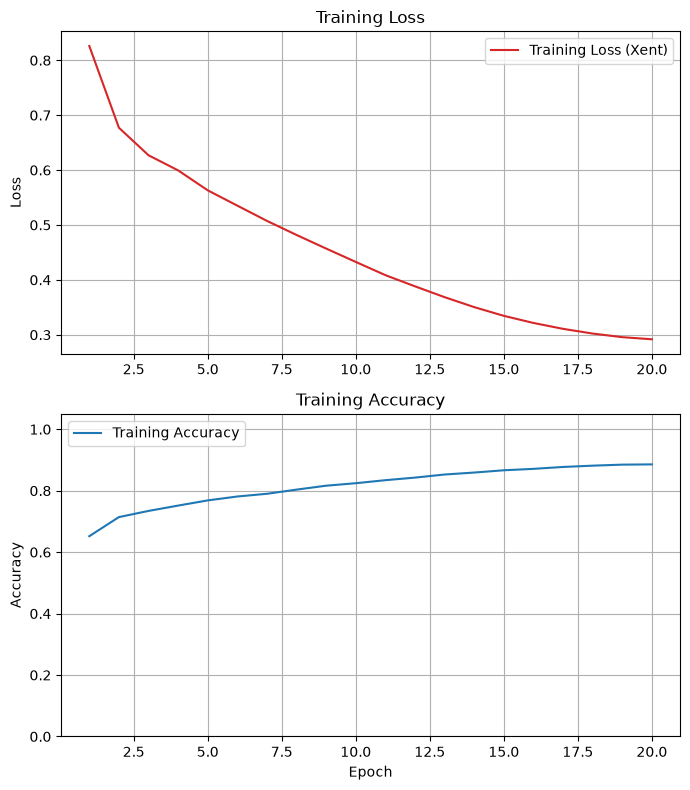

Final Training Loss:     0.2918
Final Training Accuracy: 0.8857
Test accuracy: 0.8352


In [23]:
# Your code here -- add as many cells as you need
steps_per_epoch = len(X_train) // 32
schedule = CosineDecay(initial_learning_rate=0.01, decay_steps=20 * steps_per_epoch)
best_model = build_model(lr_schedule=schedule)
history = best_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)
plot_history(history)

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

In [24]:
# Set a5a to the best training accuracy found by your best model

a5a = history.history['accuracy'][-1]             # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8857


In [26]:
# Set a5b to the test accuracy found by your best model

a5b = test_acc             # Replace 0.0 with your answer

In [27]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8352


## Reflection Questions (ungraded)

1. ***We trained on a perfectly balanced \~3.3% subset.    If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?**

   Training times went up per epoch, so the more samples means more steps per epoch. The best batch size shifted to the larger side, so the more data in smaller batches produced more updates per epoch. The best learning rate shifted higher with the increase in batch size.

2. **Batch size trade-offs. With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?***

   Smaller batches inject more noise into each gradient estimate, since each mini-batch is a smaller, less representative sample of the full training set. This noise acts like implicit regularization and it pushes the optimizer away from narrow, sharp minima that overfit the training data, toward flatter minima that generalize better. It also means more gradient updates per epoch, giving the model more chances to correct its course.

3. **More epochs, same LR. If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc?**

   Train loss should decrease and training accuracy should increase, since the model gets more exposure to the data at the same learning rate. Test accuracy would likely improve too, up to a point. If training continues well past where the model has learned the generalizable patterns, test accuracy could plateau or even decline while training accuracy keeps climbing, since the model starts overfitting to quirks in the training set rather than learning new general patterns.

4. **Epochs vs. LR. It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?**

   If LR and epochs were straightforwardly inverse, then a very low LR should need more epochs to catch the high LR. There's also an upper bound the analogy misses: too high an LR doesn't reach the goal faster.



# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


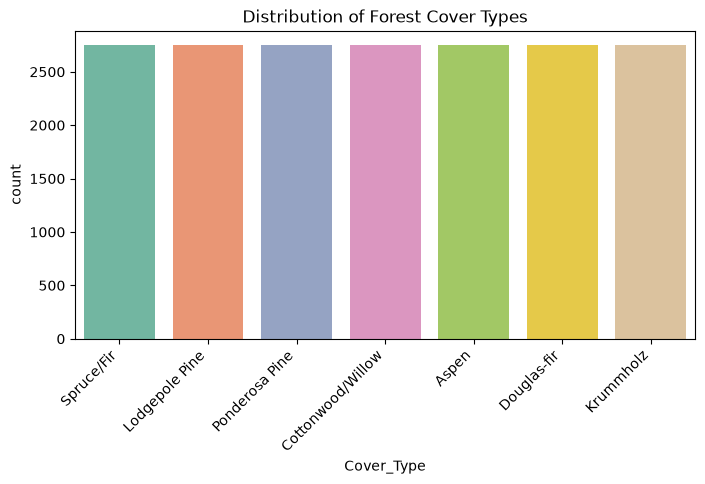

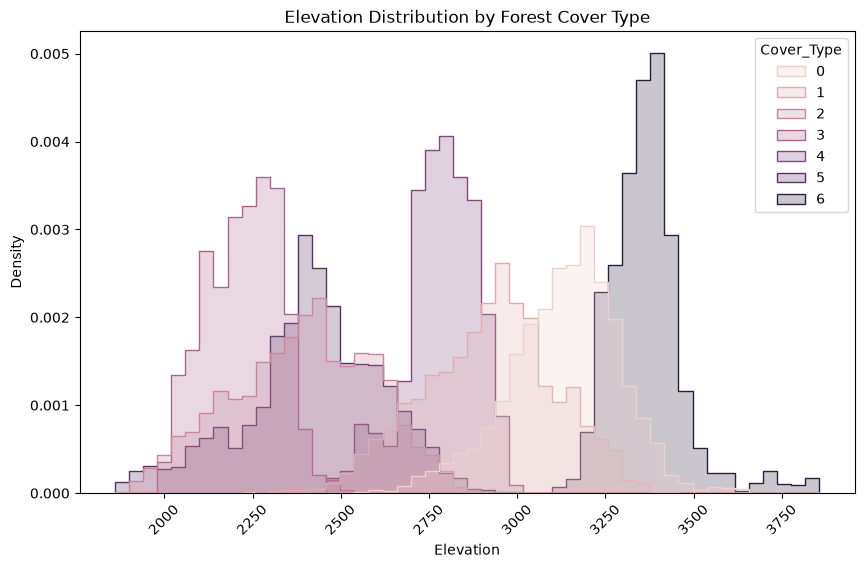

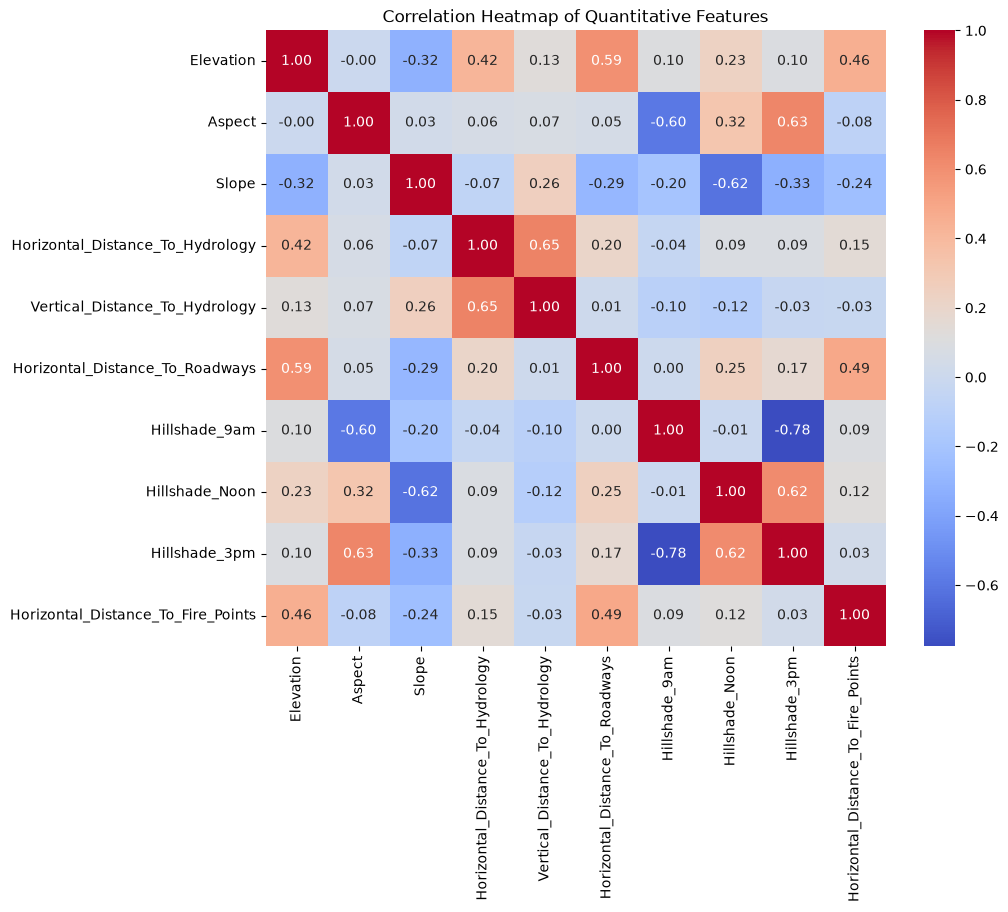

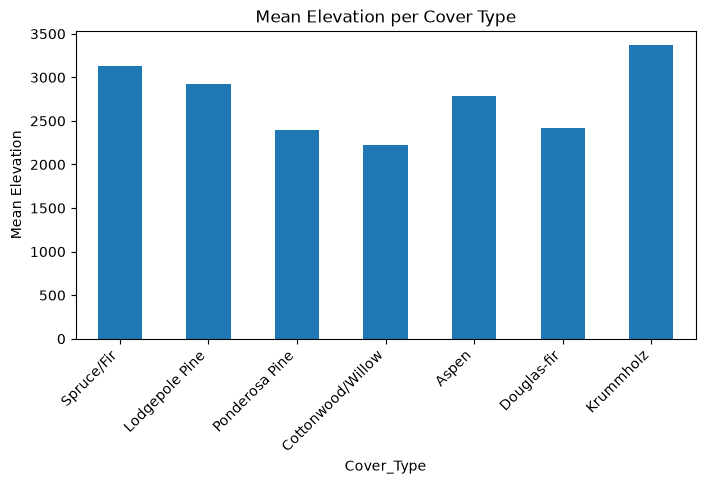

In [28]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
